# 03 — Within-subgroup drivers

Notebook 02 ended on a problem. Twenty-five of the 45 taxonomy leaves *dilute* their member
topics: the leaf total is much weaker than the strongest topic inside it. The most extreme
case is `9.2 Promise, Vow & Future-Tense Speech Acts`, where one topic reaches a Cliff's
delta of 0.225 — the largest topic-level effect in the whole corpus — and the leaf as a whole
manages 0.038.

That is not a rounding problem. It means the 22 topics inside `9.2` do not behave alike, and
summing them cancels the signal out. The purpose of this chapter is to look inside such
categories and say, concretely, which topics carry the difference and which pull against it.

**What this chapter delivers**

1. For each diluting leaf, the full internal breakdown: every topic, its effect, its size.
2. A **driver concentration** measure — is the leaf's signal one topic or a broad tendency?
3. A **coherence audit** — do a leaf's topics actually covary across books, i.e. is it one
   theme at all?
4. A **refined subindex** for the worst offenders: the same leaf restricted to the topics
   that agree, reported as exploratory and clearly flagged as post-hoc.

**The honesty constraint.** Point 4 is selection on an outcome we have already looked at, so
a refined subindex is guaranteed to look better than the leaf it came from. It is reported as
a *description of internal structure*, never as a confirmatory result, and notebook 08
re-checks it under author clustering.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = cwd
for _ in range(6):
    if (project_root / "configs").is_dir() and (project_root / "src").is_dir():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Could not find project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.stage10_correlation_analysis.analysis import effects as eff
from src.stage10_correlation_analysis.analysis import notebook_helpers as nbh
from src.stage10_correlation_analysis.analysis import reliability as rel
from src.stage10_correlation_analysis.analysis import tests as tst

ctx = nbh.setup("03_within_subgroup_drivers")
cfg = ctx.cfg
TIERS = cfg.tier_order
TIER_COL = cfg.tier_column
PALETTE = nbh.tier_palette(cfg)
HIGH, LOW = cfg.section("tiers", "headline_contrast")
GATE = float(cfg.section("screening", "effect_gates", "cliffs_delta_small"))
SEED = int(cfg.section("inference", "bootstrap", "seed"))
REPLICATES = int(cfg.section("inference", "effect_ci_replicates"))

frame = nbh.load_analysis_frame(cfg).reset_index()
topic_lookup = nbh.load_topic_lookup(cfg)
LABELS = nbh.topic_label_map(topic_lookup)

topic_effects = pd.read_csv(
    cfg.notebook_output_dirs("01_topic_landscape")["tables"] / "topic_tier_effects_full.csv"
)
aggregation = pd.read_csv(
    cfg.notebook_output_dirs("02_taxonomy_structure")["tables"] / "aggregation_gain_loss.csv"
)
leaf_effects = pd.read_csv(
    cfg.notebook_output_dirs("02_taxonomy_structure")["tables"] / "leaf_tier_effects.csv"
)
topic_effects["leaf_id"] = topic_effects["taxonomy_main_id"].astype(str)

print(f"\nLoaded {len(topic_effects)} topic-level effects and {len(leaf_effects)} leaf-level "
      f"effects from the previous two notebooks.")

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage10/final_analysis.yaml
Run          : v4_l12_granular_final_call49
Model        : BERTopic call_49 — MiniLM-L12, 374 topics (348 mapped + outliers)
Outputs      : results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/03_within_subgroup_drivers



Loaded 369 topic-level effects and 45 leaf-level effects from the previous two notebooks.


## 1. Which categories need opening up?

A leaf goes on the list if it has at least three topics (so there is something to decompose)
and either loses most of its topics' signal, or contains at least one topic that clears the
small-effect gate on its own. The second condition matters: a leaf can look uninteresting at
leaf level while containing a genuinely strong topic.

In [2]:
min_topics = 3
targets = aggregation[
    (aggregation["n_topics_tested"] >= min_topics)
    & ((aggregation["retention"] < 0.6) | (aggregation["max_abs_topic_delta"] >= GATE))
].copy()
targets = targets.sort_values("max_abs_topic_delta", ascending=False).reset_index(drop=True)

print(f"{len(targets)} leaves selected for decomposition, out of "
      f"{int((aggregation['n_topics_tested'] >= min_topics).sum())} with {min_topics}+ topics.\n")
display(targets[["leaf_id", "leaf_name", "main_group", "n_topics_tested", "abs_leaf_delta",
                 "max_abs_topic_delta", "retention", "sign_split", "verdict"]].round(3))
ctx.save_table(targets, "decomposition_targets")

28 leaves selected for decomposition, out of 32 with 3+ topics.



,leaf_id,leaf_name,main_group,n_topics_tested,abs_leaf_delta,max_abs_topic_delta,retention,sign_split,verdict
0,9.2,"Promise, Vow & Future-Tense Speech Acts",Auxiliary Style & Discourse Flags,24,0.0360,0.2250,0.1590,0.2920,dilutes
1,7.1,Interpersonal Non-Romantic Conflict,"Conflict, Risk & Harm",3,0.1040,0.1660,0.6300,0.0000,preserves
2,7.2,"Violence, Threats & Non-Sexual Coercion","Conflict, Risk & Harm",12,0.1520,0.1650,0.9200,0.0000,preserves
3,4.6,"Emotional Safety, Reassurance & Caretaking",Relationship Trajectory (Main Couple),30,0.0920,0.1600,0.5740,0.1330,dilutes
4,5.1,"Family, Kinship & Parenthood",Social World Outside Couple,6,0.0970,0.1560,0.6220,0.0000,preserves
5,1.6,Character Appearance & Self-Presentation,Embodied & Sensory Experience,15,0.1470,0.1450,1.0080,0.3330,amplifies
6,2.5,"Sexual Negotiation, Safety Preparation & Bound...","Sexuality, Attraction & Intimacy",7,0.0410,0.1440,0.2870,0.2860,dilutes
7,2.2,Kissing & Non-Explicit Affection,"Sexuality, Attraction & Intimacy",4,0.0040,0.1310,0.0330,0.2500,dilutes
8,2.3,Explicit Sexual Acts,"Sexuality, Attraction & Intimacy",7,0.0260,0.1310,0.1990,0.4290,dilutes
9,2.1,Attraction & Sexual Tension,"Sexuality, Attraction & Intimacy",17,0.0340,0.1300,0.2620,0.3530,dilutes


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/03_within_subgroup_drivers/tables/decomposition_targets.csv  (28 rows)


## 2. Driver concentration: one topic or many?

For each target leaf, two complementary numbers:

- **driver share** — the fraction of the leaf's total topic-level signal (summed absolute
  deltas) held by its single strongest topic. Near 1 means the leaf is really one topic
  wearing a category's name.
- **agreement** — the fraction of the leaf's topic-level signal pointing the same way as the
  leaf's own effect. Near 0.5 means the topics contradict each other and the leaf total is
  an artefact of which side happened to be larger.

Both are computed with topic mass as the weight, because a large topic pulling one way
outweighs a tiny topic pulling the other.

In [3]:
rows = []
for row in targets.itertuples():
    members = topic_effects[topic_effects["leaf_id"] == row.leaf_id].copy()
    if members.empty:
        continue
    members["mass"] = members[["mean_a", "mean_b"]].mean(axis=1)
    members["signal"] = members["cliffs_delta"].abs() * members["mass"]
    total_signal = float(members["signal"].sum())
    leaf_sign = np.sign(row.cliffs_delta) if row.cliffs_delta != 0 else 1.0
    agreeing = float(members.loc[np.sign(members["cliffs_delta"]) == leaf_sign, "signal"].sum())

    strongest = members.reindex(members["cliffs_delta"].abs().sort_values(ascending=False).index)
    rows.append({
        "leaf_id": row.leaf_id,
        "leaf_name": row.leaf_name,
        "main_group": row.main_group,
        "n_topics": int(len(members)),
        "leaf_delta": row.cliffs_delta,
        "driver_share": float(strongest.iloc[0]["signal"] / total_signal) if total_signal else np.nan,
        "top3_driver_share": float(strongest.head(3)["signal"].sum() / total_signal) if total_signal else np.nan,
        "agreement": agreeing / total_signal if total_signal else np.nan,
        "strongest_topic": strongest.iloc[0]["label"],
        "strongest_delta": float(strongest.iloc[0]["cliffs_delta"]),
        "n_above_gate": int((members["cliffs_delta"].abs() >= GATE).sum()),
        "n_opposing_above_gate": int(
            ((members["cliffs_delta"].abs() >= GATE)
             & (np.sign(members["cliffs_delta"]) != leaf_sign)).sum()
        ),
    })

concentration = pd.DataFrame(rows).sort_values("agreement").reset_index(drop=True)
concentration["structure"] = np.where(
    concentration["agreement"] >= 0.8, "coherent",
    np.where(concentration["agreement"] >= 0.6, "mixed", "contradictory"),
)

display(concentration.round(3))
ctx.save_table(concentration, "driver_concentration")

print(f"\ncoherent (topics broadly agree)       : {int((concentration['structure'] == 'coherent').sum())}")
print(f"mixed                                 : {int((concentration['structure'] == 'mixed').sum())}")
print(f"contradictory (topics pull both ways) : {int((concentration['structure'] == 'contradictory').sum())}")
print("\nA contradictory leaf is not a failed measurement — it is evidence that the taxonomy")
print("category bundles distinguishable narrative behaviours. That is a finding about the")
print("taxonomy, and it is the reason the axes in notebook 04 are built from leaves that")
print("survive this check rather than from every leaf that exists.")

,leaf_id,leaf_name,main_group,n_topics,leaf_delta,driver_share,top3_driver_share,agreement,strongest_topic,strongest_delta,n_above_gate,n_opposing_above_gate,structure
0,8.4,"Time, Seasons & Temporal Framing","Spaces, Time, Activities & Objects",3,-0.0000,0.9070,1.0000,0.0930,Counting Months and Waiting,0.0370,0,0,contradictory
1,4.2,Ongoing Courtship & Everyday Relational Bonding,Relationship Trajectory (Main Couple),14,-0.0010,0.0460,0.2800,0.3610,Conversation Cut Short By Arrival,0.0720,0,0,contradictory
2,2.2,Kissing & Non-Explicit Affection,"Sexuality, Attraction & Intimacy",4,-0.0040,0.4330,0.9760,0.4330,Lingering Farewell Kiss,-0.1310,2,1,contradictory
3,9.4,Interior Monologue Particles & Self-Talk,Auxiliary Style & Discourse Flags,7,-0.0110,0.1080,0.5150,0.4670,Asking For A Moment,0.1100,1,1,contradictory
4,3.3,Ambivalence & Internal Conflict,"Emotions, Cognition & Inner Life",20,-0.0560,0.1430,0.2800,0.4810,Eyes Closed on Command,0.1250,1,1,contradictory
5,2.3,Explicit Sexual Acts,"Sexuality, Attraction & Intimacy",7,0.0260,0.2220,0.3960,0.5200,Gripping Her Neck and Pulling Close,0.1310,2,0,contradictory
6,2.5,"Sexual Negotiation, Safety Preparation & Bound...","Sexuality, Attraction & Intimacy",7,-0.0410,0.3560,0.7610,0.5250,Worrying About An Unplanned Pregnancy,0.1440,1,1,contradictory
7,2.1,Attraction & Sexual Tension,"Sexuality, Attraction & Intimacy",17,-0.0340,0.1820,0.3380,0.5680,Stepping Out of Panties and Jeans,-0.1300,2,1,contradictory
8,4.4,"Conflict, Distance & Breakup Threats",Relationship Trajectory (Main Couple),8,-0.0320,0.2610,0.3640,0.5760,Pissed Off and Grumbling,0.0740,0,0,contradictory
9,8.3b,Everyday Props & Communication Media,"Spaces, Time, Activities & Objects",9,0.0110,0.4150,0.6690,0.6260,Phone Numbers Exchanged,0.0790,0,0,mixed


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/03_within_subgroup_drivers/tables/driver_concentration.csv  (28 rows)

coherent (topics broadly agree)       : 12
mixed                                 : 7
contradictory (topics pull both ways) : 9

A contradictory leaf is not a failed measurement — it is evidence that the taxonomy
category bundles distinguishable narrative behaviours. That is a finding about the
taxonomy, and it is the reason the axes in notebook 04 are built from leaves that
survive this check rather than from every leaf that exists.


## 3. Coherence audit: do a leaf's topics covary at all?

The previous section asked whether topics agree about *rating*. This one asks something more
basic: do they even co-occur? If a category's topics appear in unrelated books, then adding
their shares together produces a number with no single referent.

Three measures, from `analysis/reliability.py`:

- **Cronbach's alpha** — internal consistency of the topics as a scale
- **PC1 explained** — how much of the topics' joint variation is one dimension
- **mean pairwise correlation** — the plainest version of the same question

Caution: topic shares are compositional and mutually constrained, which pushes correlations
*down* mechanically. So low values here should be read as "no evidence of a shared
dimension" rather than as proof of independence, and the comparison across leaves is more
informative than any single value.

In [4]:
coherence_rows = []
for row in concentration.itertuples():
    members = topic_effects[topic_effects["leaf_id"] == row.leaf_id]["feature"].tolist()
    members = [c for c in members if c in frame.columns]
    if len(members) < 2:
        continue
    block = frame[members]
    corr = block.corr(method="spearman").to_numpy()
    off_diagonal = corr[~np.eye(len(members), dtype=bool)]
    pca = rel.pca_structure(block, n_components=2)
    coherence_rows.append({
        "leaf_id": row.leaf_id,
        "leaf_name": row.leaf_name,
        "n_topics": len(members),
        "cronbach_alpha": rel.cronbach_alpha(block),
        "pc1_explained": float(pca.loc[0, "explained_variance_ratio"]) if len(pca) else np.nan,
        "pc1_all_same_sign": bool(pca.loc[0, "all_loadings_same_sign"]) if len(pca) else False,
        "mean_pairwise_r": float(np.mean(off_diagonal)),
        "max_pairwise_r": float(np.max(off_diagonal)),
        "share_negative_pairs": float(np.mean(off_diagonal < 0)),
    })

coherence = pd.DataFrame(coherence_rows).sort_values("mean_pairwise_r", ascending=False)
display(coherence.round(4))
ctx.save_table(coherence, "leaf_coherence_audit")

merged = concentration.merge(
    coherence[["leaf_id", "cronbach_alpha", "pc1_explained", "mean_pairwise_r"]],
    on="leaf_id", how="left",
)
print(
    "\nPut sections 2 and 3 together. A leaf whose topics neither co-occur (low mean pairwise\n"
    "correlation) nor agree about rating (agreement near 0.5) is a label, not a construct.\n"
    "A leaf whose topics disagree about rating but do co-occur is more interesting: the same\n"
    "narrative territory handled in ways readers evaluate differently."
)
ctx.save_table(merged, "structure_and_coherence")

,leaf_id,leaf_name,n_topics,cronbach_alpha,pc1_explained,pc1_all_same_sign,mean_pairwise_r,max_pairwise_r,share_negative_pairs
27,8.1,Domestic Spaces & Routines,4,0.4048,0.4476,True,0.3255,0.5016,0.0000
2,2.2,Kissing & Non-Explicit Affection,4,0.5912,0.4764,True,0.3087,0.7844,0.0000
23,5.1,"Family, Kinship & Parenthood",6,0.5590,0.3281,True,0.2953,0.5401,0.0000
10,1.2,"Pain, Injury & Physical Vulnerability",5,0.4171,0.4380,False,0.2474,0.6304,0.2000
20,10.1,Paranormal & Immortal Beings,8,0.3700,0.2456,True,0.2368,0.4581,0.0000
9,8.3b,Everyday Props & Communication Media,9,0.4826,0.2353,True,0.1899,0.5380,0.0833
24,7.2,"Violence, Threats & Non-Sexual Coercion",12,0.4334,0.1902,False,0.1486,0.5379,0.1818
14,1.7,Facial Expression & Non-Sexual Nonverbal Cues,21,0.3922,0.1966,False,0.1424,0.7198,0.2524
12,4.5,"Reconciliation, Commitments & HEA",8,0.2514,0.2305,False,0.1276,0.3709,0.1429
1,4.2,Ongoing Courtship & Everyday Relational Bonding,14,0.2443,0.1524,False,0.1211,0.5833,0.2418


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/03_within_subgroup_drivers/tables/leaf_coherence_audit.csv  (28 rows)

Put sections 2 and 3 together. A leaf whose topics neither co-occur (low mean pairwise
correlation) nor agree about rating (agreement near 0.5) is a label, not a construct.
A leaf whose topics disagree about rating but do co-occur is more interesting: the same
narrative territory handled in ways readers evaluate differently.
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/03_within_subgroup_drivers/tables/structure_and_coherence.csv  (28 rows)


## 4. Inside the categories: the driver tables

The detail behind the summaries. For each target leaf, every member topic with its own
effect, sorted so drivers appear first and opponents last. `mass_pp` is the topic's mean
share of a book's sentences in percentage points, so a large delta on a tiny topic is
visibly distinguishable from a large delta on a substantial one.

### Failure, partial failure, success

The six panels below give a visual pattern that recurs throughout the analysis:

- **9.2 Promise, Vow & Future-Tense Speech Acts** — topics scatter widely around zero; the
  leaf total collapses to near zero. Aggregation **failed**: only ~16% of the strongest
  internal signal survives.
- **4.6 Emotional Safety, Reassurance & Caretaking** — predominantly positive topics, but
  some drag the leaf toward zero. About 57% of the strongest topic survives. The concept
  is **meaningful but too broad**.
- **7.2 Violence, Threats & Non-Sexual Coercion** — nearly all topics pull the same way;
  the leaf total closely tracks the strongest individual topic (~92% retained).
  Aggregation **succeeded** because the category is statistically coherent.

In [5]:
detail_frames = []
for row in concentration.head(8).itertuples():
    members = topic_effects[topic_effects["leaf_id"] == row.leaf_id].copy()
    members["mass_pp"] = members[["mean_a", "mean_b"]].mean(axis=1) * 100
    members["shift_pp"] = members["hodges_lehmann_shift"] * 100
    members["role"] = np.where(
        np.sign(members["cliffs_delta"]) == np.sign(row.leaf_delta), "with the leaf", "against"
    )
    members["leaf_id"] = row.leaf_id
    members["leaf_name"] = row.leaf_name
    members = members.reindex(members["cliffs_delta"].sort_values(ascending=False).index)

    print(f"\n{'=' * 100}")
    print(f"{row.leaf_id}  {row.leaf_name}")
    print(f"leaf delta {row.leaf_delta:+.3f} | {row.n_topics} topics | "
          f"agreement {row.agreement:.2f} | structure {row.structure}")
    print("=" * 100)
    display(members[["label", "mass_pp", "cliffs_delta", "ci_low", "ci_high", "magnitude",
                     "shift_pp", "role", "q_value"]].round(4).reset_index(drop=True))
    detail_frames.append(members)

drivers = pd.concat(detail_frames, ignore_index=True)
ctx.save_table(drivers, "within_leaf_topic_detail")


8.4  Time, Seasons & Temporal Framing
leaf delta -0.000 | 3 topics | agreement 0.09 | structure contradictory


,label,mass_pp,cliffs_delta,ci_low,ci_high,magnitude,shift_pp,role,q_value
0,Counting Months and Waiting,0.4006,0.0373,0.0163,0.0603,negligible,0.0095,against,0.0057
1,Remarking on Someone's Age,0.3150,-0.0008,-0.0242,0.0195,negligible,0.0000,with the leaf,0.7897
2,Squinting to Read The Watch,0.0601,-0.0215,-0.0435,0.0017,negligible,0.0000,with the leaf,0.1760



4.2  Ongoing Courtship & Everyday Relational Bonding
leaf delta -0.001 | 14 topics | agreement 0.36 | structure contradictory


,label,mass_pp,cliffs_delta,ci_low,ci_high,magnitude,shift_pp,role,q_value
0,Conversation Cut Short By Arrival,0.0692,0.0723,0.0582,0.0875,negligible,0.0000,against,0.0000
1,Warm Greeting Upon Return,0.1542,0.0537,0.0329,0.0755,negligible,0.0080,against,0.0000
2,First Name Used at Last,0.3471,0.0504,0.0275,0.0742,negligible,0.0146,against,0.0001
3,Talking About Dogs and Animals,0.2744,0.0481,0.0260,0.0692,negligible,0.0116,against,0.0001
4,Admitting Shared Pain,0.3412,0.0442,0.0192,0.0654,negligible,0.0131,against,0.0006
5,Ranch Life and Falling in Love,0.1469,0.0392,0.0199,0.0597,negligible,0.0012,against,0.0009
6,Watching Movies Together,0.1722,0.0261,0.0028,0.0487,negligible,0.0041,against,0.0863
7,Curious About Her Cooking Skills,0.1188,0.0072,-0.0148,0.0293,negligible,0.0000,against,0.0388
8,Sorting Out Concert Tickets,0.0884,-0.0022,-0.0243,0.0176,negligible,0.0000,with the leaf,0.9711
9,Swept Onto The Dance Floor,0.1552,-0.0199,-0.0416,0.0026,negligible,-0.0014,with the leaf,0.1167



2.2  Kissing & Non-Explicit Affection
leaf delta -0.004 | 4 topics | agreement 0.43 | structure contradictory


...


2.5  Sexual Negotiation, Safety Preparation & Boundaries
leaf delta -0.041 | 7 topics | agreement 0.52 | structure contradictory


,label,mass_pp,cliffs_delta,ci_low,ci_high,magnitude,shift_pp,role,q_value
0,Worrying About An Unplanned Pregnancy,0.2722,0.1438,0.1226,0.1677,small,0.0339,against,0.0000
1,Agreeing to Stop When Asked,0.1955,0.0672,0.0457,0.0871,negligible,0.0118,against,0.0000
2,Cherishing Memories Before Parting,0.1686,-0.0072,-0.0294,0.0142,negligible,-0.0010,with the leaf,0.6977
3,Stepping Into The Bathroom,0.1202,-0.0254,-0.0460,-0.0024,negligible,-0.0027,with the leaf,0.0615
4,Reaching Into The Bedside Drawer,0.0722,-0.0499,-0.0736,-0.0271,negligible,0.0000,with the leaf,0.0000
5,Furnished Room Described in Detail,0.2883,-0.0641,-0.0896,-0.0405,negligible,-0.0175,with the leaf,0.0000
6,Choosing Sex Without Commitment,0.3217,-0.0977,-0.1180,-0.0749,negligible,-0.0329,with the leaf,0.0000



2.1  Attraction & Sexual Tension
leaf delta -0.034 | 17 topics | agreement 0.57 | structure contradictory


,label,mass_pp,cliffs_delta,ci_low,ci_high,magnitude,shift_pp,role,q_value
0,Tattoos Revealed and Judged,0.0573,0.1193,0.0982,0.1397,small,0.0035,against,0.0000
1,Stop Running or Be Claimed,0.1612,0.0833,0.0617,0.1024,negligible,0.0133,against,0.0000
2,Waiting As Long As It Takes,0.2734,0.0651,0.0421,0.0865,negligible,0.0121,against,0.0000
3,Promising to Be A Good Team,0.1584,0.0497,0.0269,0.0706,negligible,0.0075,against,0.0000
4,Blue Eyes Darkening With Invitation,0.3808,0.0469,0.0260,0.0687,negligible,0.0203,against,0.0002
5,Confessing Long-Simmering Desire,0.3483,0.0444,0.0222,0.0669,negligible,0.0139,against,0.0005
6,Lip Biting and Nervous Pout,0.1532,0.0436,0.0225,0.0658,negligible,0.0083,against,0.0003
7,Admiring Her Grace and Beauty,0.6686,0.0280,0.0048,0.0484,negligible,0.0201,against,0.0420
8,Legs Wrapped Around His Waist,0.8081,0.0069,-0.0129,0.0295,negligible,0.0074,against,0.8241
9,Eyes Meeting Across The Room,1.0538,0.0052,-0.0162,0.0292,negligible,0.0086,against,0.5174


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/03_within_subgroup_drivers/tables/within_leaf_topic_detail.csv  (79 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/03_within_subgroup_drivers/figures/within_leaf_forest_panels.png


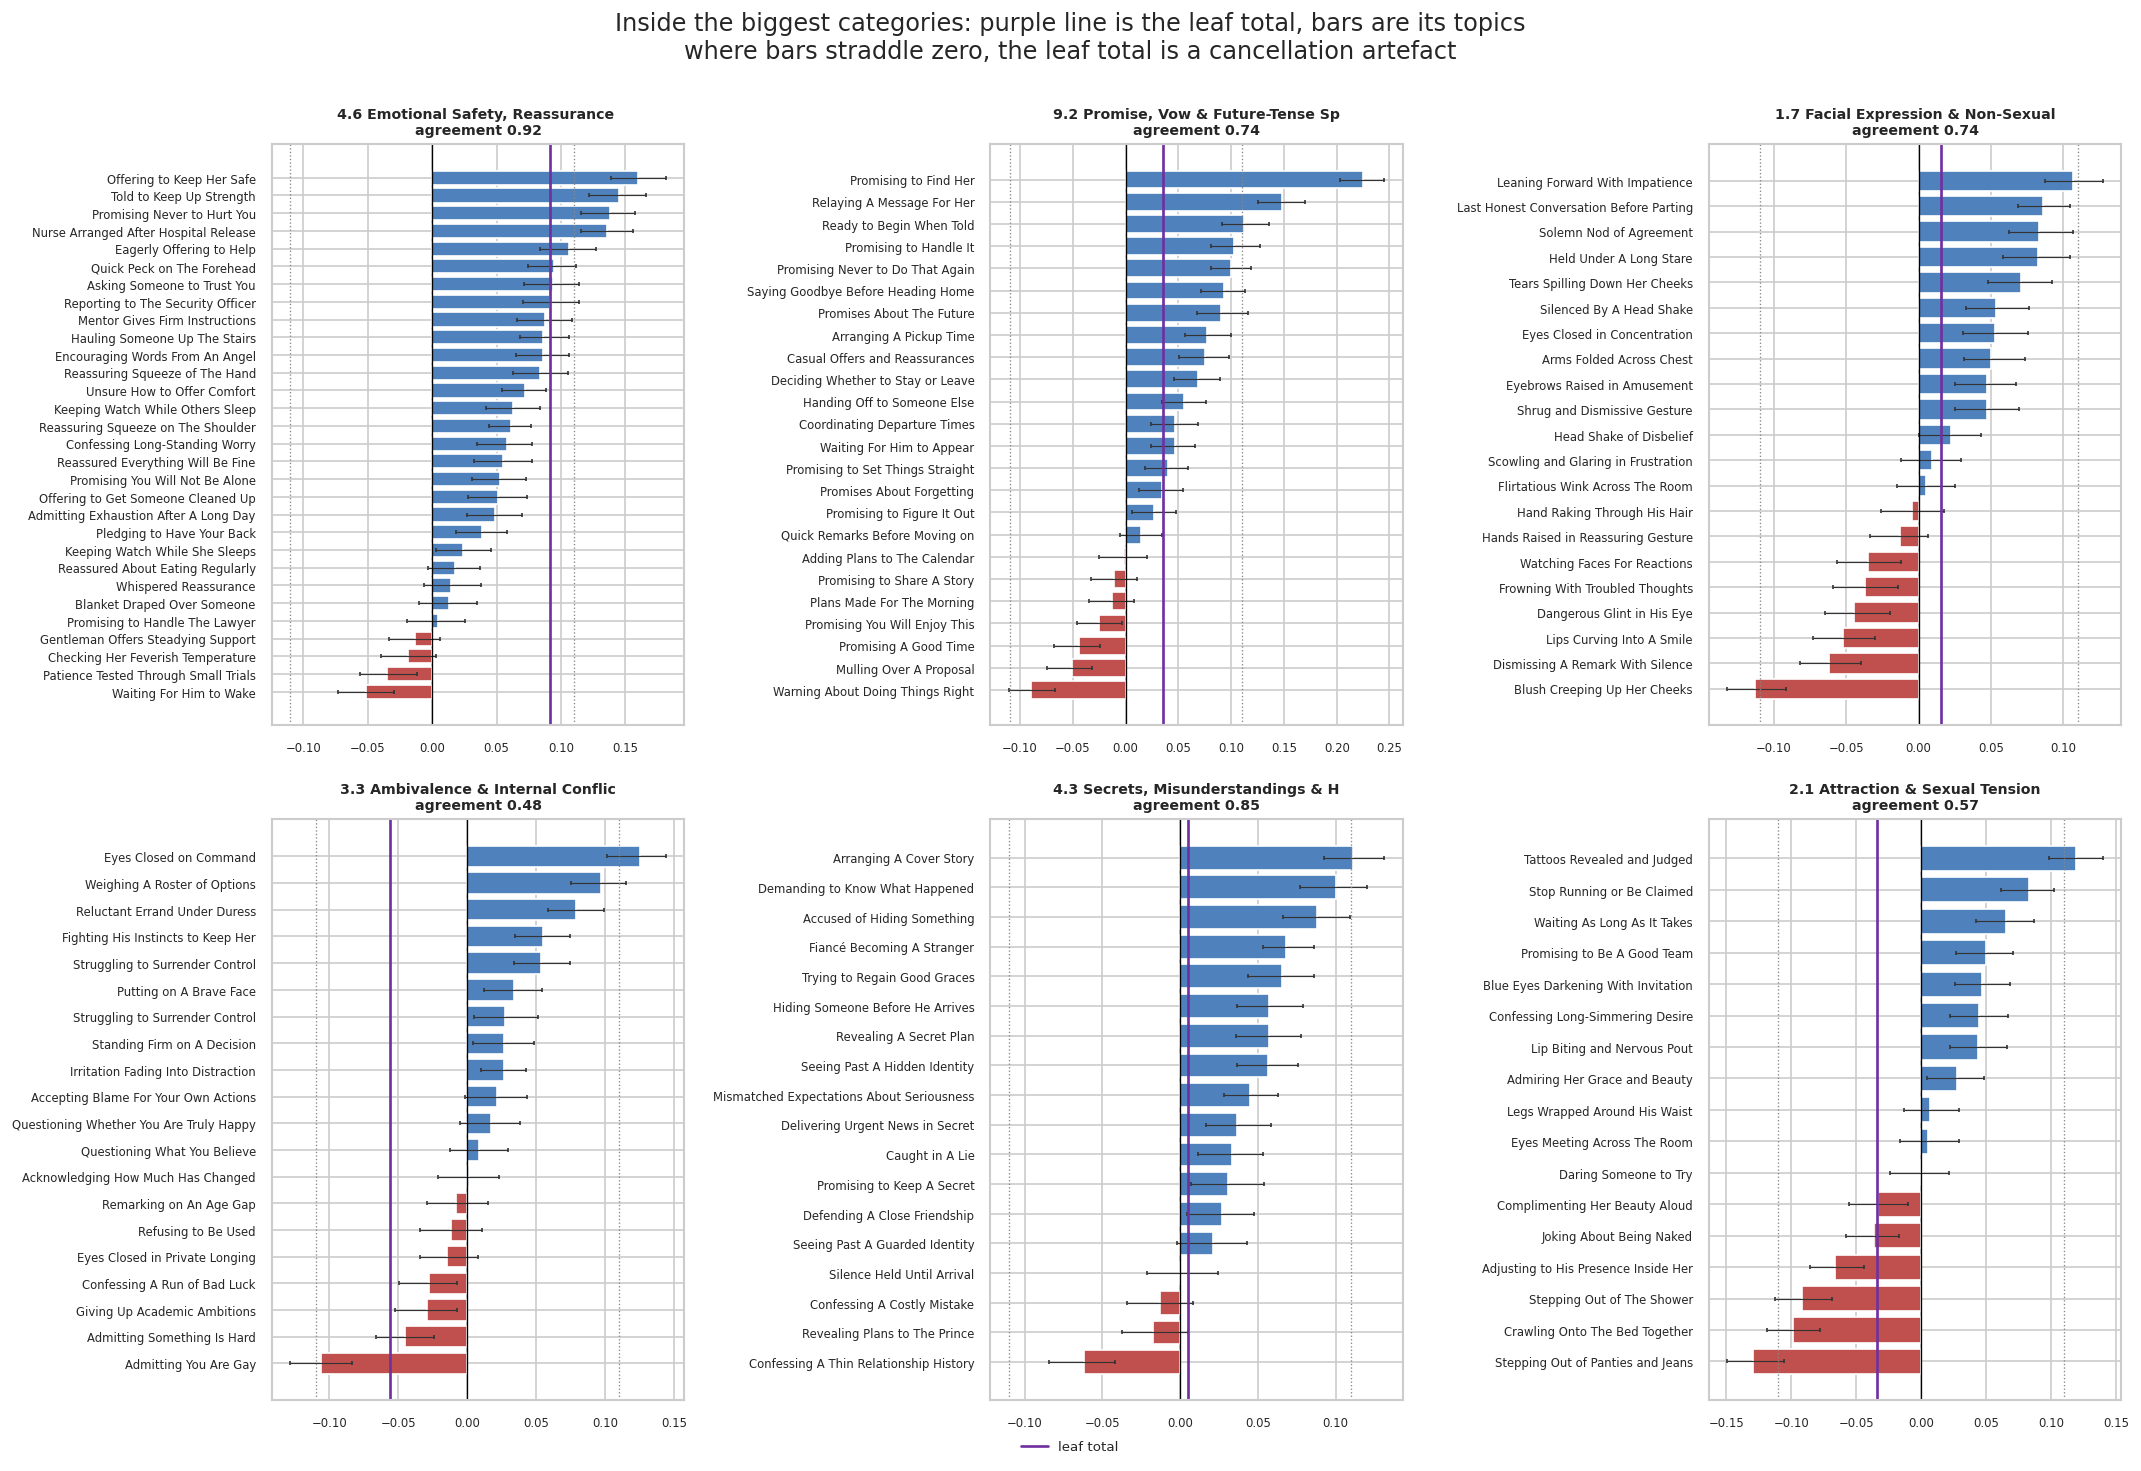

In [6]:
import textwrap as _tw

n_panels = min(6, len(concentration))
panel_leaves = concentration.reindex(
    concentration["n_topics"].sort_values(ascending=False).index
).head(n_panels)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()
_shared_handles = None
for ax, row in zip(axes, panel_leaves.itertuples()):
    members = topic_effects[topic_effects["leaf_id"] == row.leaf_id].copy()
    members = members.reindex(members["cliffs_delta"].sort_values().index)
    y = np.arange(len(members))
    colours = [PALETTE[HIGH] if d > 0 else PALETTE[LOW] for d in members["cliffs_delta"]]
    ax.barh(y, members["cliffs_delta"], color=colours)
    ax.errorbar(members["cliffs_delta"], y,
                xerr=[members["cliffs_delta"] - members["ci_low"],
                      members["ci_high"] - members["cliffs_delta"]],
                fmt="none", ecolor="#333333", elinewidth=0.7, capsize=1.2)
    ax.set_yticks(y)
    ax.set_yticklabels([_tw.shorten(str(v), 42, placeholder="…") for v in members["label"]],
                       fontsize=7)
    ax.axvline(0, color="black", lw=0.8)
    lh = ax.axvline(row.leaf_delta, color="#7030a0", ls="-", lw=1.6, label="leaf total")
    for gate_value in (GATE, -GATE):
        ax.axvline(gate_value, color="#888888", ls=":", lw=0.8)
    ax.set_title(f"{row.leaf_id} {str(row.leaf_name)[:30]}\nagreement {row.agreement:.2f}",
                 fontsize=8.5)
    ax.tick_params(axis="x", labelsize=7)
    if _shared_handles is None:
        _shared_handles = [lh]

for ax in axes[len(panel_leaves):]:
    ax.axis("off")
fig.suptitle("Inside the biggest categories: purple line is the leaf total, bars are its topics\n"
             "where bars straddle zero, the leaf total is a cancellation artefact", y=1.0)
fig.legend(_shared_handles, ["leaf total"], loc="lower center", ncol=1,
           bbox_to_anchor=(0.5, -0.01), fontsize=8, frameon=False)
fig.tight_layout(pad=1.1, w_pad=1.4, h_pad=1.4)
ctx.save_figure(fig, "within_leaf_forest_panels")
plt.show()

## 5. Refined subindices — exploratory

For the contradictory leaves, what happens if the category is split into the topics that
agree and the topics that oppose, and each half is measured on its own?

**This is post-hoc.** The split is chosen using the same tier contrast it is then evaluated
on, so the two halves are *guaranteed* to separate more than the leaf did. The number worth
reading is not the effect size but the pair of labels: what do the agreeing topics have in
common, and what do the opposing ones? That is a description of internal structure, and it
is the kind of claim that the qualitative close readings in notebook 07 can check.

In [7]:
refined_rows = []
subindex_columns = {}
for row in concentration[concentration["structure"] != "coherent"].itertuples():
    members = topic_effects[topic_effects["leaf_id"] == row.leaf_id].copy()
    members = members[members["feature"].isin(frame.columns)]
    if len(members) < 4:
        continue
    leaf_sign = np.sign(row.leaf_delta) if row.leaf_delta != 0 else 1.0
    with_leaf = members.loc[np.sign(members["cliffs_delta"]) == leaf_sign, "feature"].tolist()
    against = members.loc[np.sign(members["cliffs_delta"]) != leaf_sign, "feature"].tolist()
    if len(with_leaf) < 2 or len(against) < 2:
        continue

    name_with = f"sub_{row.leaf_id}_aligned"
    name_against = f"sub_{row.leaf_id}_opposed"
    subindex_columns[name_with] = frame[with_leaf].sum(axis=1)
    subindex_columns[name_against] = frame[against].sum(axis=1)

    refined_rows.append({
        "leaf_id": row.leaf_id,
        "leaf_name": row.leaf_name,
        "leaf_delta": row.leaf_delta,
        "n_aligned": len(with_leaf),
        "n_opposed": len(against),
        "aligned_topics": "; ".join(str(LABELS.get(c, c))[:30] for c in with_leaf[:4]),
        "opposed_topics": "; ".join(str(LABELS.get(c, c))[:30] for c in against[:4]),
    })

if subindex_columns:
    sub_frame = pd.concat([frame[[TIER_COL]], pd.DataFrame(subindex_columns, index=frame.index)],
                          axis=1)
    sub_effects = eff.two_group_effects(
        sub_frame, list(subindex_columns), TIER_COL, HIGH, LOW,
        n_replicates=REPLICATES, seed=SEED,
    )
    refined = pd.DataFrame(refined_rows)
    for suffix, label in [("aligned", "aligned"), ("opposed", "opposed")]:
        lookup = sub_effects.set_index("feature")
        refined[f"{label}_delta"] = [
            float(lookup.loc[f"sub_{lid}_{suffix}", "cliffs_delta"])
            for lid in refined["leaf_id"]
        ]
    refined["separation"] = refined["aligned_delta"] - refined["opposed_delta"]
    refined = refined.sort_values("separation", key=lambda s: s.abs(), ascending=False)

    display(refined[["leaf_id", "leaf_name", "leaf_delta", "aligned_delta", "opposed_delta",
                     "separation", "n_aligned", "n_opposed"]].round(4))
    print("\nWhat the two halves contain:")
    display(refined[["leaf_id", "aligned_topics", "opposed_topics"]])
    ctx.save_table(refined, "refined_subindices_exploratory")
    ctx.save_table(sub_effects, "refined_subindex_effects")
else:
    refined = pd.DataFrame()
    print("No leaf had at least two topics on each side; no refined subindices built.")

,leaf_id,leaf_name,leaf_delta,aligned_delta,opposed_delta,separation,n_aligned,n_opposed
12,9.2,"Promise, Vow & Future-Tense Speech Acts",0.0357,0.1548,-0.1244,0.2792,17,7
4,2.5,"Sexual Negotiation, Safety Preparation & Bound...",-0.0413,-0.1273,0.1317,-0.2590,5,2
3,2.3,Explicit Sexual Acts,0.0260,0.0810,-0.1314,0.2124,4,3
11,1.7,Facial Expression & Non-Sexual Nonverbal Cues,0.0152,0.1049,-0.1073,0.2122,13,8
8,1.2,"Pain, Injury & Physical Vulnerability",0.0437,0.1372,-0.0576,0.1948,3,2
1,9.4,Interior Monologue Particles & Self-Talk,-0.0108,-0.0983,0.0809,-0.1791,4,3
5,2.1,Attraction & Sexual Tension,-0.0339,-0.1424,0.0327,-0.1751,6,11
2,3.3,Ambivalence & Internal Conflict,-0.0561,-0.0820,0.0717,-0.1537,7,13
7,8.3b,Everyday Props & Communication Media,0.0114,0.0788,-0.0732,0.1519,5,4
9,4.5,"Reconciliation, Commitments & HEA",0.0268,0.0973,-0.0474,0.1447,6,2



What the two halves contain:


,leaf_id,aligned_topics,opposed_topics
12,9.2,Promising to Find Her; Relaying A Message For ...,Warning About Doing Things Rig; Mulling Over A...
4,2.5,Choosing Sex Without Commitmen; Furnished Room...,Worrying About An Unplanned Pr; Agreeing to St...
3,2.3,Gripping Her Neck and Pulling ; Tongue and Han...,Erection Straining Against His; Kissing With T...
11,1.7,Leaning Forward With Impatienc; Last Honest Co...,Blush Creeping Up Her Cheeks; Dismissing A Rem...
8,1.2,Wound Bleeding and Blood Loss; Scars Fading Ov...,Sweat Pouring From A Wound; Ribs Pounding With...
1,9.4,Pausing Unsure What to Say; Remarking on An Un...,Asking For A Moment; Called Out For Being Dist...
5,2.1,Stepping Out of Panties and Je; Crawling Onto ...,Tattoos Revealed and Judged; Stop Running or B...
2,3.3,Admitting You Are Gay; Admitting Something Is ...,Eyes Closed on Command; Weighing A Roster of O...
7,8.3b,Phone Numbers Exchanged; Directed to Take A Se...,Opening An Envelope or Documen; Sipping Coffee...
9,4.5,Confessing How Much You've Mis; Promising to C...,Admitting You've Been Stupid; Declaring A True...


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/03_within_subgroup_drivers/tables/refined_subindices_exploratory.csv  (13 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/03_within_subgroup_drivers/tables/refined_subindex_effects.csv  (26 rows)


## 6. The single strongest topic in the corpus, in context

Worth one section on its own. `9.2 Promise, Vow & Future-Tense Speech Acts` has the largest
topic-level effect anywhere in this analysis and almost none of it survives aggregation. The
breakdown below is the clearest single illustration of why this chapter exists.

The taxonomy grouped together different kinds of "future-oriented language." Some may
represent meaningful commitment; some may be promises about unrelated actions, threats of
leaving, procedural future tense, etc. When all of those are counted as one thing, the
strong narrative function disappears. The taxonomy itself already distinguishes formal
promise wording from actual relationship commitment: real commitment/reconciliation belongs
under **4.5**, whereas 9.2 is primarily a discourse-form category. That distinction is the
seed of the contextual refinement carried out in Stage 11.

Strongest topic anywhere: 'Promising to Find Her'
  Cliff's delta +0.225 [0.203, 0.245]
  taxonomy leaf 9.2 — Promise, Vow & Future-Tense Speech Acts
  the leaf as a whole: delta +0.036 (24 topics)


,label,mass_pp,cliffs_delta,ci_low,ci_high,magnitude
0,Promising to Find Her,0.7085,0.2251,0.2034,0.2449,small
1,Relaying A Message For Her,0.3858,0.1482,0.1249,0.1695,small
2,Ready to Begin When Told,0.3501,0.1124,0.0916,0.1356,small
3,Promising to Handle It,0.0947,0.1030,0.0805,0.1273,negligible
4,Promising Never to Do That Again,0.0607,0.0996,0.0808,0.1188,negligible
5,Saying Goodbye Before Heading Home,0.1904,0.0927,0.0710,0.1127,negligible
6,Promises About The Future,0.1447,0.0902,0.0678,0.1155,negligible
7,Arranging A Pickup Time,0.2531,0.0773,0.0561,0.0994,negligible
8,Casual Offers and Reassurances,0.4793,0.0753,0.0506,0.0979,negligible
9,Deciding Whether to Stay or Leave,0.4548,0.0685,0.0463,0.0896,negligible


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/03_within_subgroup_drivers/figures/strongest_topic_in_context.png


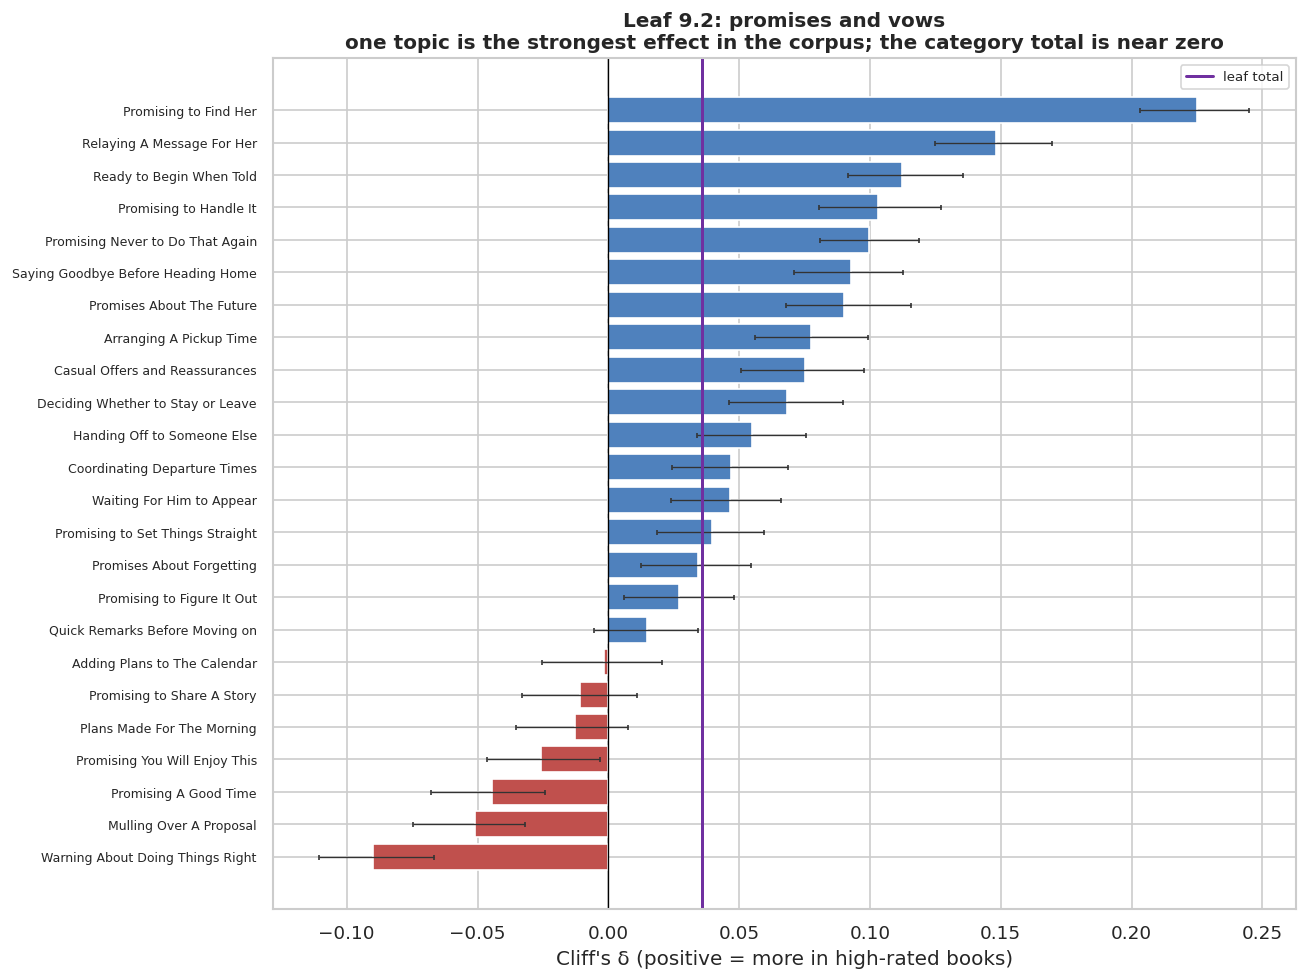

In [8]:
strongest_row = topic_effects.reindex(
    topic_effects["cliffs_delta"].abs().sort_values(ascending=False).index
).iloc[0]
host_leaf = str(strongest_row["leaf_id"])

print(f"Strongest topic anywhere: {strongest_row['label']!r}")
print(f"  Cliff's delta {strongest_row['cliffs_delta']:+.3f} "
      f"[{strongest_row['ci_low']:.3f}, {strongest_row['ci_high']:.3f}]")
print(f"  taxonomy leaf {host_leaf} — {strongest_row['taxonomy_main_name']}")

host = leaf_effects[leaf_effects["leaf_id"].astype(str) == host_leaf]
if len(host):
    print(f"  the leaf as a whole: delta {float(host.iloc[0]['cliffs_delta']):+.3f} "
          f"({host.iloc[0]['n_topics']} topics)")

siblings = topic_effects[topic_effects["leaf_id"] == host_leaf].copy()
siblings["mass_pp"] = siblings[["mean_a", "mean_b"]].mean(axis=1) * 100
siblings = siblings.reindex(siblings["cliffs_delta"].sort_values(ascending=False).index)
display(siblings[["label", "mass_pp", "cliffs_delta", "ci_low", "ci_high", "magnitude"]]
        .round(4).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(11, 0.3 * len(siblings) + 2))
y = np.arange(len(siblings))[::-1]
colours = [PALETTE[HIGH] if d > 0 else PALETTE[LOW] for d in siblings["cliffs_delta"]]
ax.barh(y, siblings["cliffs_delta"], color=colours)
ax.errorbar(siblings["cliffs_delta"], y,
            xerr=[siblings["cliffs_delta"] - siblings["ci_low"],
                  siblings["ci_high"] - siblings["cliffs_delta"]],
            fmt="none", ecolor="#333333", elinewidth=0.8, capsize=1.5)
ax.set_yticks(y)
ax.set_yticklabels([str(v)[:44] for v in siblings["label"]], fontsize=7.5)
ax.axvline(0, color="black", lw=0.8)
if len(host):
    ax.axvline(float(host.iloc[0]["cliffs_delta"]), color="#7030a0", lw=1.8,
               label="leaf total")
    ax.legend(fontsize=8)
ax.set_xlabel("Cliff's δ (positive = more in high-rated books)")
ax.set_title(f"Leaf {host_leaf}: promises and vows\n"
             "one topic is the strongest effect in the corpus; the category total is near zero")
ctx.save_figure(fig, "strongest_topic_in_context")
plt.show()

## 7. What this chapter changes for the rest of the analysis

Three consequences, all acted on downstream.

In [9]:
summary = pd.DataFrame([
    ("leaves decomposed", f"{len(concentration)}"),
    ("coherent leaves", f"{int((concentration['structure'] == 'coherent').sum())}"),
    ("mixed leaves", f"{int((concentration['structure'] == 'mixed').sum())}"),
    ("contradictory leaves", f"{int((concentration['structure'] == 'contradictory').sum())}"),
    ("most one-topic-driven leaf",
     f"{concentration.loc[concentration['driver_share'].idxmax(), 'leaf_id']} "
     f"(driver share {concentration['driver_share'].max():.2f})"),
    ("strongest topic overall", f"{strongest_row['label']} "
                                f"(delta {strongest_row['cliffs_delta']:+.3f}, leaf {host_leaf})"),
    ("refined subindices built", f"{len(refined)} (exploratory only)"),
], columns=["item", "value"])
display(summary)
ctx.save_table(summary, "chapter_summary")

print(
    "\nConsequences carried forward:\n"
    "  1. Axes in notebook 04 are validated with alpha, omega and PCA on their components\n"
    "     before use, precisely because leaf-level aggregation has been shown to cancel.\n"
    "  2. Where a hypothesis rests on a contradictory leaf, the hypothesis test in notebook 05\n"
    "     reports the leaf form as primary and the topic-level detail alongside it, rather\n"
    "     than quietly substituting whichever version is stronger.\n"
    "  3. The close readings in notebook 07 are sampled on the axes, and the aligned/opposed\n"
    "     splits found here are what they are asked to interpret.\n"
)
print("Next: 04_composites_validity.ipynb — building the theory axes and testing whether they")
print("hold together well enough to carry a hypothesis.")

,item,value
0,leaves decomposed,28
1,coherent leaves,12
2,mixed leaves,7
3,contradictory leaves,9
4,most one-topic-driven leaf,8.4 (driver share 0.91)
5,strongest topic overall,"Promising to Find Her (delta +0.225, leaf 9.2)"
6,refined subindices built,13 (exploratory only)


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/03_within_subgroup_drivers/tables/chapter_summary.csv  (7 rows)

Consequences carried forward:
  1. Axes in notebook 04 are validated with alpha, omega and PCA on their components
     before use, precisely because leaf-level aggregation has been shown to cancel.
  2. Where a hypothesis rests on a contradictory leaf, the hypothesis test in notebook 05
     reports the leaf form as primary and the topic-level detail alongside it, rather
     than quietly substituting whichever version is stronger.
  3. The close readings in notebook 07 are sampled on the axes, and the aligned/opposed
     splits found here are what they are asked to interpret.

Next: 04_composites_validity.ipynb — building the theory axes and testing whether they
hold together well enough to carry a hypothesis.
